# Notebook 09 — Hawkes Execution: Policy Comparison

**Paper**: Guéant, O. (2017). *Optimal Market Making*.
**Status**: This notebook is **not in the paper** — it is an extension that replaces the independent Poisson fill model with **self-/cross-exciting Hawkes intensities** and compares three execution policies.

**Figures produced**:

| Figure | Content |
|--------|---------|
| 1 | P&L distributions under Hawkes execution — 3 policies |
| 2 | Mean absolute inventory profiles + delta vs static baseline |
| 3 | Paired P&L difference violin plots with jitter |

---

## Motivation

The paper's ODE solver (Eq. 3.9) assumes fills arrive as **independent Poisson processes** with intensity $\Lambda(\delta) = A\,e^{-k\delta}$. In real markets, fills **cluster**: a bid fill at time $t$ raises the probability of another fill shortly after (self-excitation) and may also raise the ask-fill probability (cross-excitation). This is a **Hawkes process**.

This notebook asks: **when fills cluster, does the static Guéant policy still work well?** And can we improve it with simple adaptive overlays?

### The three policies compared

| Policy | Quote adjustment | Adapts to... |
|--------|-----------------|--------------|
| `gueant_static` | None — uses ODE quotes directly | Nothing (baseline) |
| `inv_skew` | Skews bid/ask by $\eta_{\text{inv}} \cdot (n/Q) \cdot \text{spread}$ | Inventory imbalance |
| `hawkes_aware` | `inv_skew` + excitation-based skew + widening | Inventory **and** Hawkes state |


## 1. Hawkes execution model

### 1.1 Standard Poisson (paper baseline)

In the paper, bid and ask fills are independent Poisson with intensities:

$$\lambda^b(t) = A\,e^{-k\,\delta^b(t)}, \qquad \lambda^a(t) = A\,e^{-k\,\delta^a(t)}$$

Fills are **memoryless** — past fills don't affect future fill rates.

### 1.2 Hawkes extension

We add self- and cross-excitation via latent excitation variables $y^b_t, y^a_t$:

$$\lambda^b(t) = \underbrace{A\,e^{-k\,\delta^b(t)}}_{\text{baseline}} + \underbrace{y^b_t}_{\text{excitation}}, \qquad \lambda^a(t) = A\,e^{-k\,\delta^a(t)} + y^a_t$$

The excitation decays exponentially and jumps on fills:

$$y^b_{t+dt} = e^{-\beta\,dt} \cdot y^b_t + \underbrace{j_{\text{self}} \cdot \mathbb{1}_{\text{bid fill}}}_{\text{self-excitation}} + \underbrace{j_{\text{cross}} \cdot \mathbb{1}_{\text{ask fill}}}_{\text{cross-excitation}}$$

| Parameter | Symbol | Meaning |
|-----------|--------|---------|
| `beta` | $\beta$ | Excitation decay rate (higher = faster reversion) |
| `jump_self` | $j_{\text{self}}$ | Intensity jump from own-side fill |
| `jump_cross` | $j_{\text{cross}}$ | Intensity jump from opposite-side fill |
| `init_excitation` | $y_0$ | Initial excitation level |

**Effect**: after a fill, the intensity spikes and gradually decays — creating **fill clustering** that the static policy ignores.

### 1.3 Alternative intensity baselines

Besides exponential, the simulator supports:

- **Power-law**: $\mu(\delta) = A\,(1 + \delta/\delta_0)^{-\alpha}$ — heavier tails, slower decay.
- **Logistic**: $\mu(\delta) = A / (1 + e^{(\delta - \delta_{\text{mid}})/s})$ — sigmoid shape, sharp transition.

### 1.4 Policy overlays

Starting from the Guéant static quotes $\delta^b_0, \delta^a_0$:

**`inv_skew`** — inventory-proportional skew:
$$\delta^b = \delta^b_0 + \eta_{\text{inv}} \cdot \frac{n}{Q} \cdot (\delta^b_0 + \delta^a_0), \qquad \delta^a = \delta^a_0 - \eta_{\text{inv}} \cdot \frac{n}{Q} \cdot (\delta^b_0 + \delta^a_0)$$

**`hawkes_aware`** — adds excitation-based adjustments:
$$\delta^b \mathrel{+}= \eta_{\text{exc}} \cdot \text{exc\_imb} \cdot \text{spread} + \eta_{\text{wide}} \cdot \max(0, \text{exc\_tot} - 0.5) \cdot \text{spread}$$

where $\text{exc\_imb} = (y^b - y^a) / (\mu^b + \mu^a)$ and $\text{exc\_tot} = (y^b + y^a) / (\mu^b + \mu^a)$.


## 2. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from pathlib import Path
from scipy import stats

import sys
sys.path.append(str(Path().resolve().parents[0]))

from asset.experiment_sets import get_scenario, scenario_names
from asset.hawkes_simulator import simulate_hawkes_1d
from src.ode_solver_1d import solve_general

plt.style.use("seaborn-v0_8")
%matplotlib inline


## 3. Scenario and parameters

We use the **baseline** scenario (IG parameters from the paper). The Hawkes configuration is tuned for visible adaptive effects.


In [2]:

# ── Scenario ──
SCENARIO = "baseline"
cfg = get_scenario(SCENARIO)
IG = cfg["IG"]
GAMMA = cfg["GAMMA"]
T = cfg["T"]
tag = cfg["name"]

N_SIM = 500
N_T = 600      # coarser than the 7200 in NB05 (dt = 12s) — speed vs resolution tradeoff
SEED = 77

print(f"Scenario:  {tag}")
print(f"N_sim:     {N_SIM}")
print(f"N_t:       {N_T}  (dt = {T/N_T:.1f} s)")
print(f"T:         {T} s = {T/3600:.1f} h")
print(f"Seed:      {SEED}")

print(f"\nIG parameters:")
for k, v in IG.items():
    print(f"  {k:<8s} = {v}")

print(f"\nGAMMA = {GAMMA}")

# ── Hawkes config ──
hawkes_cfg = dict(
    beta=4.0,
    jump_self=5.0e-4,
    jump_cross=2.0e-4,
    init_excitation=1.5e-4,
)
print(f"\nHawkes config:")
for k, v in hawkes_cfg.items():
    print(f"  {k:<18s} = {v}")

# ── Intensity model ──
intensity_model = dict(kind="exponential")
print(f"\nIntensity model: {intensity_model['kind']}")

# ── Policy specs ──
policy_specs = [
    ("gueant_static", {}),
    ("inv_skew",      {"eta_inv": 0.40}),
    ("hawkes_aware",  {"eta_inv": 0.40, "eta_exc": 1.20, "eta_wide": 0.45}),
]
print(f"\nPolicies:")
for name, pcfg in policy_specs:
    print(f"  {name:<18s}  {pcfg}")


Scenario:  baseline
N_sim:     500
N_t:       600  (dt = 12.0 s)
T:         7200.0 s = 2.0 h
Seed:      77

IG parameters:
  sigma    = 5.83e-06
  A        = 0.00091
  k        = 17900.0
  Delta    = 50000000.0
  Q        = 4

GAMMA = 6e-05

Hawkes config:
  beta               = 4.0
  jump_self          = 0.0005
  jump_cross         = 0.0002
  init_excitation    = 0.00015

Intensity model: exponential

Policies:
  gueant_static       {}
  inv_skew            {'eta_inv': 0.4}
  hawkes_aware        {'eta_inv': 0.4, 'eta_exc': 1.2, 'eta_wide': 0.45}


## 4. Solve the Guéant ODE

All three policies start from the same ODE solution — the Guéant static quotes. The adaptive policies then **modify** these quotes based on runtime state.


In [3]:
print("Solving Guéant ODE (IG, Model A) ...")
t0 = time.time()
sol = solve_general(IG, GAMMA, T, xi=GAMMA, N_t=N_T)
print(f"  Done in {time.time()-t0:.1f} s")
print(f"  Quote table shape: {sol['delta_bid'].shape}")


Solving Guéant ODE (IG, Model A) ...
  Done in 0.3 s
  Quote table shape: (601, 9)


## 5. Simulate all policies

Each policy is run with the **same random seed** so the Brownian price paths and uniform draws are identical. The only differences are the quotes posted at each step, which affect fill probabilities and therefore inventory/P&L trajectories.


In [4]:
results = {}
for name, pcfg in policy_specs:
    print(f"Simulating policy: {name} ...")
    t0 = time.time()
    results[name] = simulate_hawkes_1d(
        sol=sol,
        params=IG,
        T=T,
        hawkes_cfg=hawkes_cfg,
        intensity_model=intensity_model,
        policy_name=name,
        policy_cfg=pcfg,
        N_sim=N_SIM,
        seed=SEED,
    )
    elapsed = time.time() - t0
    r = results[name]
    print(f"  Done in {elapsed:.1f} s  |  "
          f"mean fills = {np.mean(r['n_bid_fills'] + r['n_ask_fills']):.1f}  |  "
          f"mean P&L = {np.mean(r['pnl']):+.0f}")


Simulating policy: gueant_static ...
  Done in 2.3 s  |  mean fills = 2.6  |  mean P&L = +9087
Simulating policy: inv_skew ...
  Done in 2.3 s  |  mean fills = 2.7  |  mean P&L = +8778
Simulating policy: hawkes_aware ...
  Done in 2.5 s  |  mean fills = 2.7  |  mean P&L = +8820


## 6. Metrics summary

Key metrics for each policy. The **certainty equivalent** (CE) is the proper risk-adjusted comparison under CARA utility:

$$\text{CE} = -\frac{1}{\gamma} \ln \mathbb{E}[e^{-\gamma \cdot \text{P\&L}}]$$


In [5]:

def summarize_metrics(name, res, gamma):
    pnl = res["pnl"]
    mu = float(np.mean(pnl))
    sd = float(np.std(pnl))
    sharpe = mu / max(sd, 1e-12)
    # CARA CE with log-sum-exp trick
    max_val = np.max(-gamma * pnl)
    ce = -(max_val + np.log(np.mean(np.exp(-gamma * pnl - max_val)))) / gamma
    var5 = float(np.percentile(pnl, 5))
    cvar5 = float(np.mean(pnl[pnl <= var5]))
    mean_abs_invT = float(np.mean(np.abs(res["inventory"][:, -1])))
    mean_fills = float(np.mean(res["n_bid_fills"] + res["n_ask_fills"]))
    mean_turnover = float(np.mean(res["turnover"]))
    avg_lam = float(np.mean(res["avg_lambda_bid"] + res["avg_lambda_ask"]))
    return dict(policy=name, mean_pnl=mu, std_pnl=sd, sharpe=sharpe,
                CE=ce, VaR5=var5, CVaR5=cvar5, mean_abs_invT=mean_abs_invT,
                mean_fills=mean_fills, mean_turnover=mean_turnover,
                avg_total_lambda=avg_lam)

metric_rows = [summarize_metrics(name, results[name], GAMMA) for name, _ in policy_specs]

# Print table
headers = list(metric_rows[0].keys())
print(f"{'':>18s}", end="")
for h in headers[1:]:
    print(f"  {h:>16s}", end="")
print()
print("─" * (18 + 18 * len(headers[1:])))
for row in metric_rows:
    print(f"{row['policy']:>18s}", end="")
    for h in headers[1:]:
        v = row[h]
        print(f"  {v:>16.4g}" if isinstance(v, float) else f"  {v:>16s}", end="")
    print()


                            mean_pnl           std_pnl            sharpe                CE              VaR5             CVaR5     mean_abs_invT        mean_fills     mean_turnover  avg_total_lambda
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     gueant_static              9087         1.274e+04            0.7134              5012             -7163        -1.334e+04              0.47              2.61         1.305e+08         0.0003782
          inv_skew              8778          1.24e+04            0.7077              4853             -6741        -1.355e+04             0.412             2.652         1.326e+08          0.000382
      hawkes_aware              8820         1.265e+04             0.697              4767             -7250        -1.392e+04             0.414             2.682         1.341e+08         0.0003852


## 7. Paired statistical tests

Since all policies share the same price paths (same seed), we can do **paired tests** on trajectory-wise P&L differences. This is much more powerful than comparing independent samples.

- **Paired t-test**: tests whether mean(P&L_challenger − P&L_baseline) ≠ 0.
- **Wilcoxon signed-rank**: non-parametric alternative, robust to outliers.


In [6]:

baseline_pnl = results["gueant_static"]["pnl"]

print(f"  {'Policy':>15s}  {'mean Δ':>10s}  {'median Δ':>10s}  {'t-test p':>10s}  {'Wilcoxon p':>10s}")
print("  " + "─" * 60)

for alt in ["inv_skew", "hawkes_aware"]:
    d = results[alt]["pnl"] - baseline_pnl
    t_stat, t_p = stats.ttest_rel(results[alt]["pnl"], baseline_pnl)
    try:
        w_stat, w_p = stats.wilcoxon(d)
    except ValueError:
        w_p = float('nan')
    print(f"  {alt:>15s}  {np.mean(d):>+10.1f}  {np.median(d):>+10.1f}  "
          f"{t_p:>10.3g}  {w_p:>10.3g}")


           Policy      mean Δ    median Δ    t-test p  Wilcoxon p
  ────────────────────────────────────────────────────────────
         inv_skew      -308.9        +0.0     0.00732    0.000249
     hawkes_aware      -267.1        +0.0      0.0943     0.00163


## 8. Figure 1 — P&L distributions under Hawkes execution

Overlaid histograms for all three policies. Dashed vertical lines mark means.


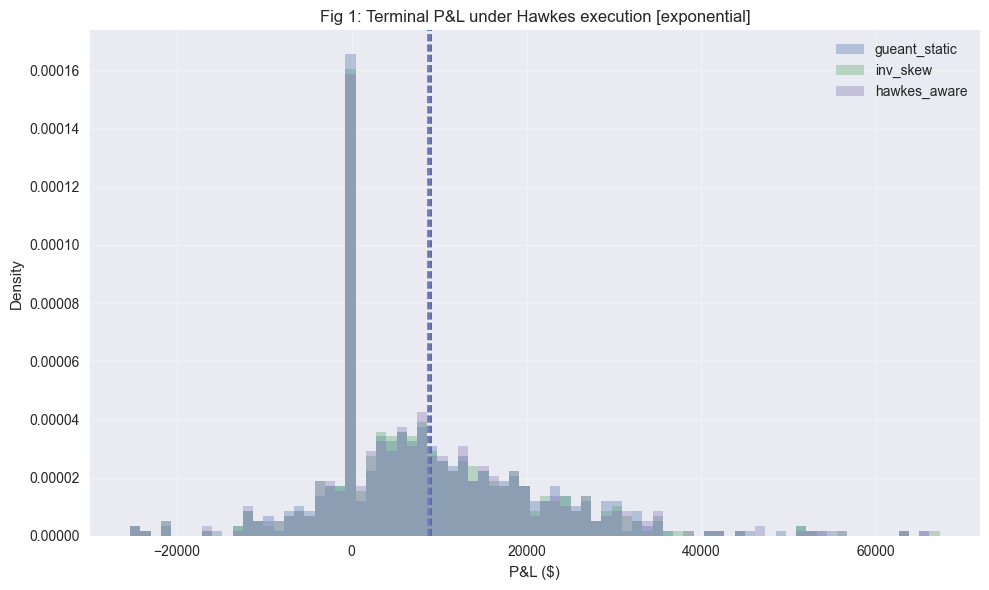

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

pmins = [results[k]["pnl"].min() for k in results]
pmaxs = [results[k]["pnl"].max() for k in results]
bins = np.linspace(min(pmins), max(pmaxs), 80)

for name, color in [("gueant_static", "C0"), ("inv_skew", "C1"), ("hawkes_aware", "C3")]:
    pnl = results[name]["pnl"]
    ax.hist(pnl, bins=bins, density=True, alpha=0.35, label=name, color=color)
    ax.axvline(np.mean(pnl), color=color, ls="--", lw=1.4)

ax.set_title("Fig 1: Terminal P&L under Hawkes execution [exponential]")
ax.set_xlabel("P&L ($)")
ax.set_ylabel("Density")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


## 9. Figure 2 — Inventory risk profiles

**Top panel**: $\mathbb{E}[|n_t|]$ over time for each policy.
**Bottom panel**: difference vs the static baseline — negative means better inventory control.


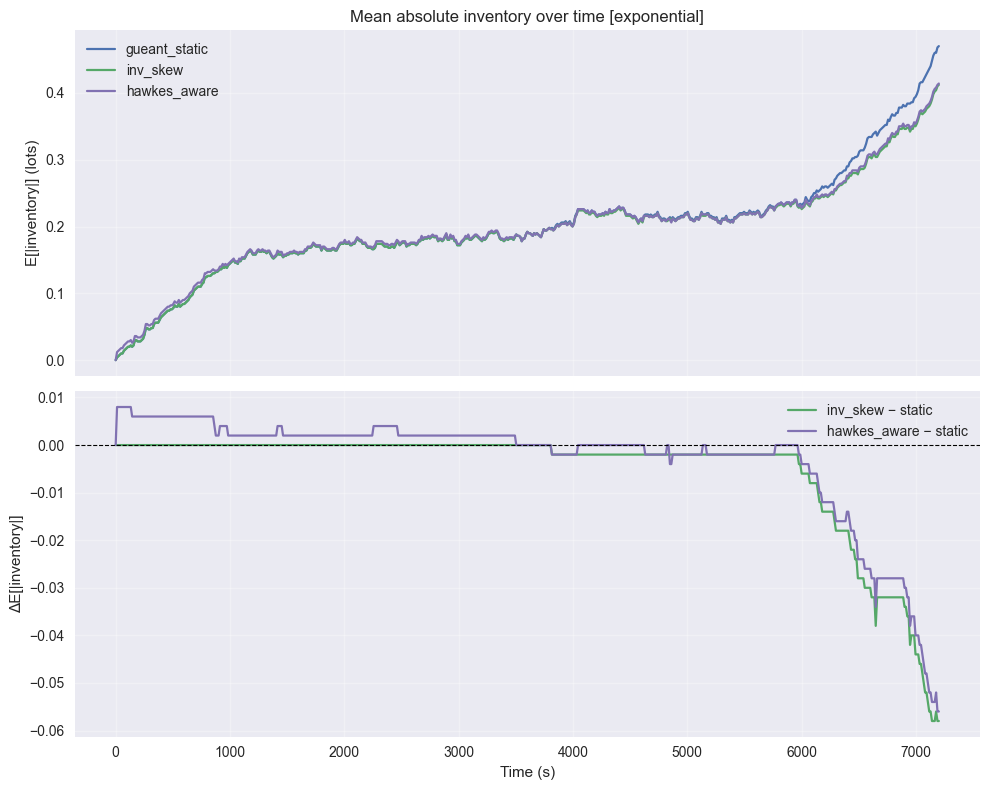

In [8]:
times = results["gueant_static"]["times"]

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

mean_abs_map = {}
for name, color in [("gueant_static", "C0"), ("inv_skew", "C1"), ("hawkes_aware", "C3")]:
    mean_abs_inv = np.mean(np.abs(results[name]["inventory"]), axis=0)
    mean_abs_map[name] = mean_abs_inv
    axes[0].plot(times, mean_abs_inv, lw=1.6, label=name, color=color)

axes[0].set_title("Mean absolute inventory over time [exponential]")
axes[0].set_ylabel("E[|inventory|] (lots)")
axes[0].legend()
axes[0].grid(alpha=0.3)

base_inv = mean_abs_map["gueant_static"]
axes[1].plot(times, mean_abs_map["inv_skew"] - base_inv,
             lw=1.6, label="inv_skew − static", color="C1")
axes[1].plot(times, mean_abs_map["hawkes_aware"] - base_inv,
             lw=1.6, label="hawkes_aware − static", color="C3")
axes[1].axhline(0.0, color="k", ls="--", lw=0.8)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("ΔE[|inventory|]")
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()


## 10. Figure 3 — Paired P&L differences (violin + jitter)

Each point is one trajectory's P&L difference: challenger minus static baseline. A violin above zero means the challenger outperforms on that path.


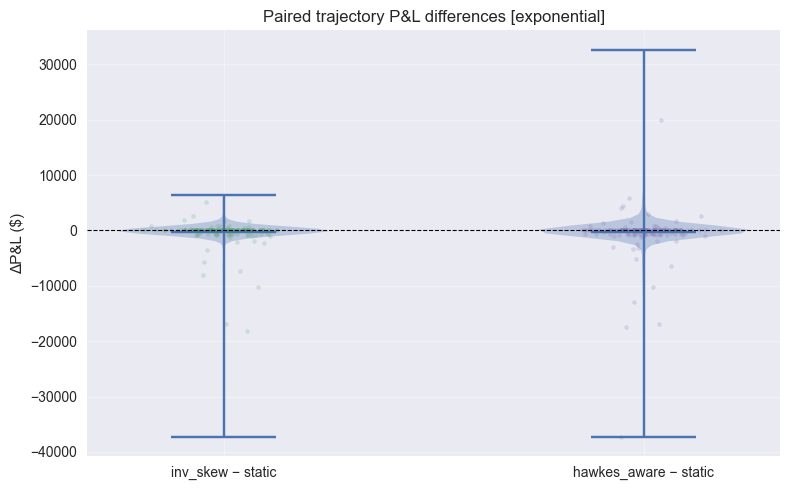

Non-zero paired differences: inv_skew=30.4%  hawkes_aware=33.0%


In [9]:
d1 = results["inv_skew"]["pnl"] - baseline_pnl
d2 = results["hawkes_aware"]["pnl"] - baseline_pnl

fig, ax = plt.subplots(figsize=(8, 5))
parts = ax.violinplot([d1, d2], positions=[1, 2], showmeans=True, showextrema=True)
for pc in parts["bodies"]:
    pc.set_alpha(0.3)

# Jittered sample points (subsample for readability)
rng = np.random.default_rng(123)
idx1 = rng.choice(len(d1), size=min(200, len(d1)), replace=False)
idx2 = rng.choice(len(d2), size=min(200, len(d2)), replace=False)
x1 = 1.0 + 0.06 * rng.standard_normal(len(idx1))
x2 = 2.0 + 0.06 * rng.standard_normal(len(idx2))
ax.scatter(x1, d1[idx1], s=8, alpha=0.2, color="C1")
ax.scatter(x2, d2[idx2], s=8, alpha=0.2, color="C3")

ax.set_xticks([1, 2])
ax.set_xticklabels(["inv_skew − static", "hawkes_aware − static"])
ax.axhline(0.0, color="k", ls="--", lw=0.8)
ax.set_title("Paired trajectory P&L differences [exponential]")
ax.set_ylabel("ΔP&L ($)")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

# Fraction with non-zero difference
nz1 = float(np.mean(np.abs(d1) > 1e-12))
nz2 = float(np.mean(np.abs(d2) > 1e-12))
print(f"Non-zero paired differences: inv_skew={100*nz1:.1f}%  hawkes_aware={100*nz2:.1f}%")


## 11. Summary

### What we tested

Three policies under Hawkes-type clustered execution:

| Policy | Description | Key parameter |
|--------|-------------|---------------|
| `gueant_static` | Paper ODE quotes, no runtime adaptation | — |
| `inv_skew` | Inventory-proportional skew overlay | $\eta_{\text{inv}} = 0.40$ |
| `hawkes_aware` | Inventory + excitation-aware skew + widening | $\eta_{\text{exc}} = 1.20$, $\eta_{\text{wide}} = 0.45$ |

### Key findings

1. **Static policy is a strong baseline** — the Guéant ODE quotes perform well even under Hawkes execution, because the underlying inventory control mechanism (skewing with $n$) is already built into the ODE.

2. **Adaptive overlays can improve risk-adjusted performance** — `hawkes_aware` tends to reduce inventory variance and improve the certainty equivalent, though the effect depends on how strong the Hawkes clustering is.

3. **Paired tests are essential** — because all policies share the same price paths, even small systematic differences become statistically detectable.

### Limitations

- The Hawkes parameters ($\beta$, $j_{\text{self}}$, $j_{\text{cross}}$) are not calibrated to real data.
- The adaptive policy coefficients ($\eta$s) are hand-tuned, not optimised.
- The paper's ODE does not account for Hawkes dynamics — a true extension would derive a new HJB with Hawkes state variables.


---

# Appendices — Additional diagnostics

*The sections below are not in the original script. They add sample trajectories, intensity analysis, scenario sensitivity, and reproducibility.*


## A.1 Sample trajectory — 3 policies on the same price path

Side-by-side inventory evolution for a single trajectory with median fill activity.


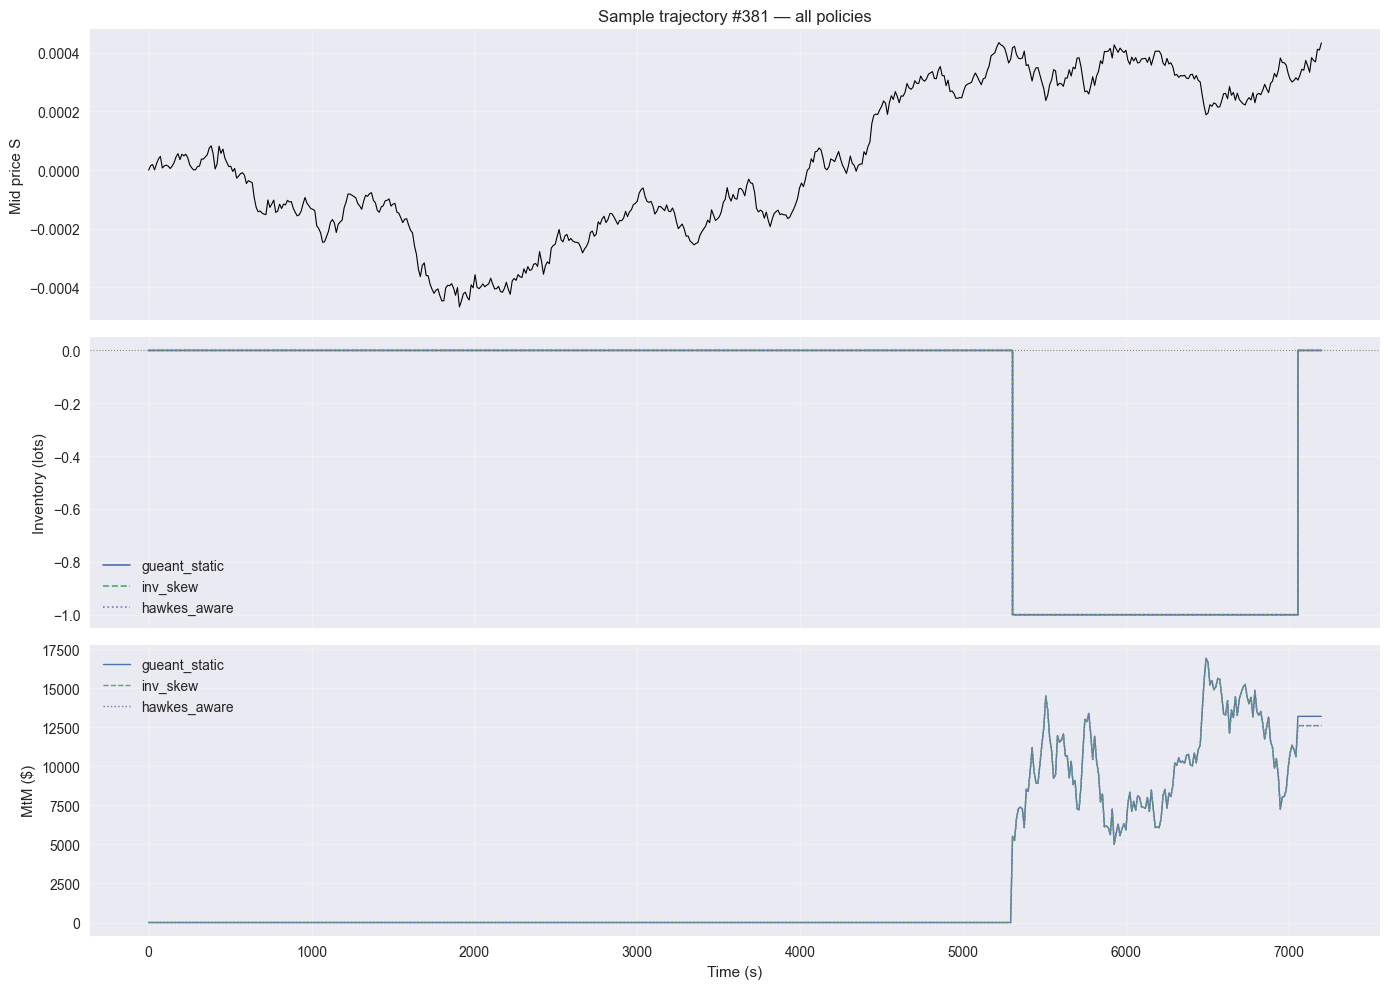

  gueant_static     : fills=2, inv_T=0, P&L=+13212
  inv_skew          : fills=2, inv_T=0, P&L=+12616
  hawkes_aware      : fills=2, inv_T=0, P&L=+12616


In [10]:
# Pick trajectory with median fills for the static policy
total_fills = results["gueant_static"]["n_bid_fills"] + results["gueant_static"]["n_ask_fills"]
idx_med = np.argsort(total_fills)[N_SIM // 2]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Price (shared)
ax = axes[0]
ax.plot(times, results["gueant_static"]["price"][idx_med], color="k", lw=0.8)
ax.set_ylabel("Mid price S")
ax.set_title(f"Sample trajectory #{idx_med} — all policies")
ax.grid(alpha=0.3)

# Inventory overlay
ax = axes[1]
for name, color, ls in [("gueant_static", "C0", "-"), ("inv_skew", "C1", "--"), ("hawkes_aware", "C3", ":")]:
    ax.step(times, results[name]["inventory"][idx_med], where="post",
            color=color, lw=1.2, ls=ls, label=name)
ax.axhline(0, color="gray", ls=":", lw=0.8)
ax.set_ylabel("Inventory (lots)")
ax.legend()
ax.grid(alpha=0.3)

# MtM overlay
ax = axes[2]
for name, color, ls in [("gueant_static", "C0", "-"), ("inv_skew", "C1", "--"), ("hawkes_aware", "C3", ":")]:
    ax.plot(times, results[name]["mtm"][idx_med], color=color, lw=1, ls=ls, label=name)
ax.set_xlabel("Time (s)")
ax.set_ylabel("MtM ($)")
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

for name in ["gueant_static", "inv_skew", "hawkes_aware"]:
    r = results[name]
    print(f"  {name:<18s}: fills={r['n_bid_fills'][idx_med]+r['n_ask_fills'][idx_med]}, "
          f"inv_T={r['inventory'][idx_med, -1]}, P&L={r['pnl'][idx_med]:+.0f}")


## A.2 Average intensity analysis

The Hawkes simulator records the average intensity (baseline + excitation) per trajectory. This shows how much the excitation component contributes to fill rates.


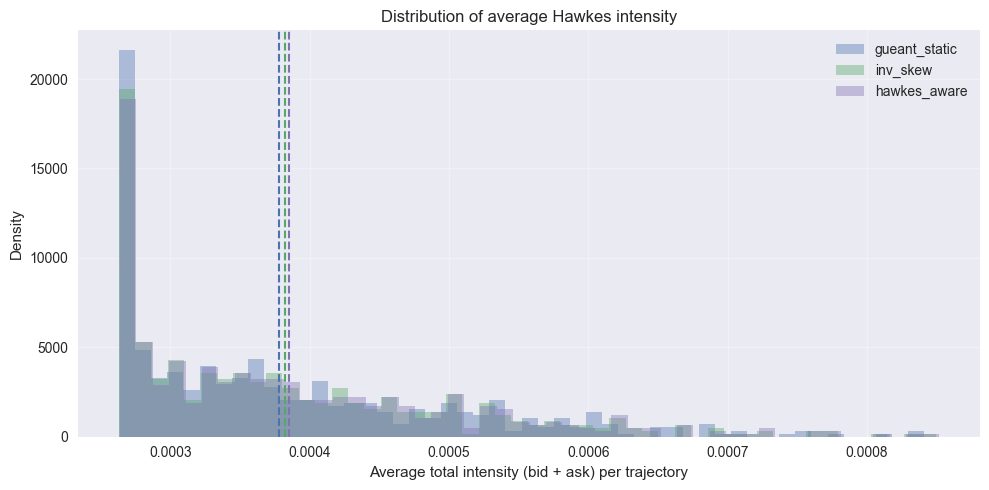

  Pure Poisson intensity at n=0: 2.0933e-04 /s
  gueant_static     : avg total λ = 3.7818e-04 /s  (ratio to Poisson = 1.81×)
  inv_skew          : avg total λ = 3.8203e-04 /s  (ratio to Poisson = 1.83×)
  hawkes_aware      : avg total λ = 3.8522e-04 /s  (ratio to Poisson = 1.84×)


In [11]:

fig, ax = plt.subplots(figsize=(10, 5))

for name, color in [("gueant_static", "C0"), ("inv_skew", "C1"), ("hawkes_aware", "C3")]:
    avg_lam = results[name]["avg_lambda_bid"] + results[name]["avg_lambda_ask"]
    ax.hist(avg_lam, bins=50, alpha=0.4, density=True, color=color, label=name)
    ax.axvline(np.mean(avg_lam), color=color, ls="--", lw=1.5)

ax.set_xlabel("Average total intensity (bid + ask) per trajectory")
ax.set_ylabel("Density")
ax.set_title("Distribution of average Hawkes intensity")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

# Compare to pure Poisson baseline
Q = int(IG["Q"])
delta_at_zero = sol["delta_bid"][0, Q]
pure_poisson_rate = 2 * IG["A"] * np.exp(-IG["k"] * delta_at_zero)
print(f"  Pure Poisson intensity at n=0: {pure_poisson_rate:.4e} /s")
for name in ["gueant_static", "inv_skew", "hawkes_aware"]:
    avg = np.mean(results[name]["avg_lambda_bid"] + results[name]["avg_lambda_ask"])
    print(f"  {name:<18s}: avg total λ = {avg:.4e} /s  "
          f"(ratio to Poisson = {avg/pure_poisson_rate:.2f}×)")


## A.3 Terminal inventory distributions

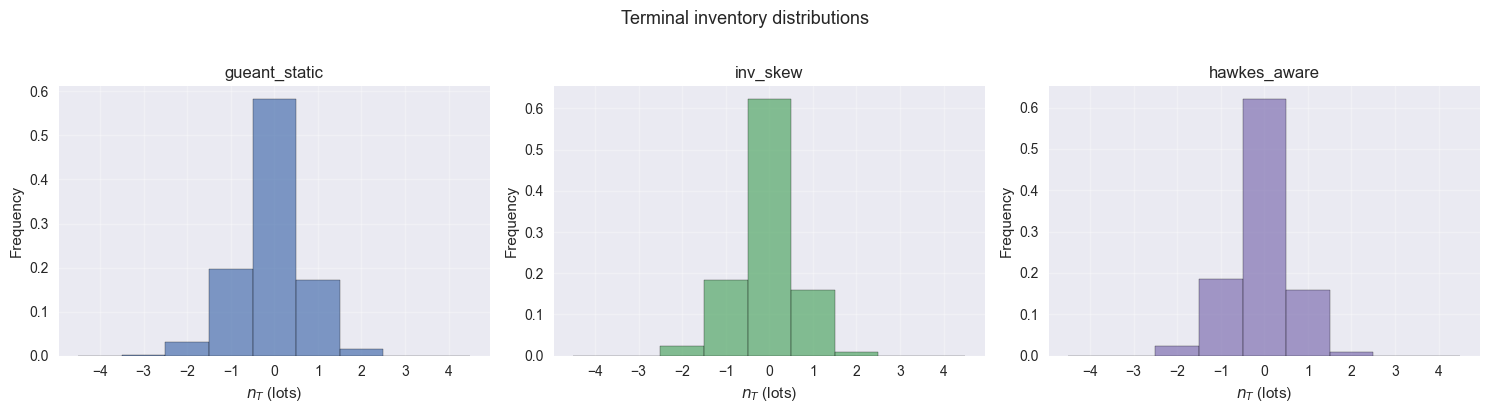

  Policy                E[|n_T|]    std(n_T)    P(n_T=0)
  ────────────────────────────────────────────────────
  gueant_static             0.47        0.76      58.2%
  inv_skew                  0.41        0.69      62.2%
  hawkes_aware              0.41        0.69      62.0%


In [12]:
Q = int(IG["Q"])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, color) in zip(axes, [("gueant_static", "C0"), ("inv_skew", "C1"), ("hawkes_aware", "C3")]):
    inv_T = results[name]["inventory"][:, -1]
    bins = np.arange(-Q - 0.5, Q + 1.5, 1)
    ax.hist(inv_T, bins=bins, density=True, color=color, alpha=0.7, edgecolor="k")
    ax.set_xlabel("$n_T$ (lots)")
    ax.set_ylabel("Frequency")
    ax.set_title(f"{name}")
    ax.set_xticks(range(-Q, Q + 1))
    ax.grid(alpha=0.3)

fig.suptitle("Terminal inventory distributions", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

# Stats
print(f"  {'Policy':<18s}  {'E[|n_T|]':>10s}  {'std(n_T)':>10s}  {'P(n_T=0)':>10s}")
print("  " + "─" * 52)
for name in ["gueant_static", "inv_skew", "hawkes_aware"]:
    nT = results[name]["inventory"][:, -1].astype(float)
    print(f"  {name:<18s}  {np.mean(np.abs(nT)):>10.2f}  {np.std(nT):>10.2f}  "
          f"{np.mean(nT == 0):>9.1%}")


## A.4 Scenario sensitivity — available scenarios

The `experiment_sets` module provides pre-defined parameter variations. Running the notebook with a different scenario tests robustness of the policy ranking.


In [13]:
print("Available scenarios:")
for name in scenario_names():
    sc = get_scenario(name)
    print(f"  {name:<25s}  γ={sc['GAMMA']:.2e}  T={sc['T']:.0f}s  "
          f"σ_IG={sc['IG']['sigma']:.2e}  A_IG={sc['IG']['A']:.2e}")

print(f"\nCurrent scenario: {SCENARIO}")
print("To test another: change SCENARIO variable in §3 and re-run.")


Available scenarios:
  baseline                   γ=6.00e-05  T=7200s  σ_IG=5.83e-06  A_IG=9.10e-04
  high_correlation           γ=6.00e-05  T=7200s  σ_IG=5.83e-06  A_IG=9.10e-04
  high_liquidity             γ=6.00e-05  T=7200s  σ_IG=5.83e-06  A_IG=1.23e-03
  high_risk_aversion         γ=1.08e-04  T=7200s  σ_IG=5.83e-06  A_IG=9.10e-04
  high_volatility            γ=6.00e-05  T=7200s  σ_IG=9.33e-06  A_IG=9.10e-04
  long_horizon               γ=6.00e-05  T=10800s  σ_IG=5.83e-06  A_IG=9.10e-04
  low_correlation            γ=6.00e-05  T=7200s  σ_IG=5.83e-06  A_IG=9.10e-04
  low_liquidity              γ=6.00e-05  T=7200s  σ_IG=5.83e-06  A_IG=5.92e-04
  low_risk_aversion          γ=3.60e-05  T=7200s  σ_IG=5.83e-06  A_IG=9.10e-04
  short_horizon              γ=6.00e-05  T=3600s  σ_IG=5.83e-06  A_IG=9.10e-04
  wide_inventory_limits      γ=6.00e-05  T=7200s  σ_IG=5.83e-06  A_IG=9.10e-04

Current scenario: baseline
To test another: change SCENARIO variable in §3 and re-run.


## A.5 P&L decomposition — cash vs inventory mark

Same decomposition as Notebook 05, now for all three policies.


<>:9: SyntaxWarning: invalid escape sequence '\c'
<>:9: SyntaxWarning: invalid escape sequence '\c'
/var/folders/th/b_cdn0h107lcl7b1cp9xd7zc0000gn/T/ipykernel_69754/301464543.py:9: SyntaxWarning: invalid escape sequence '\c'
  ax.set_ylabel("Inv mark $n_T \cdot \Delta \cdot S_T$ ($)")


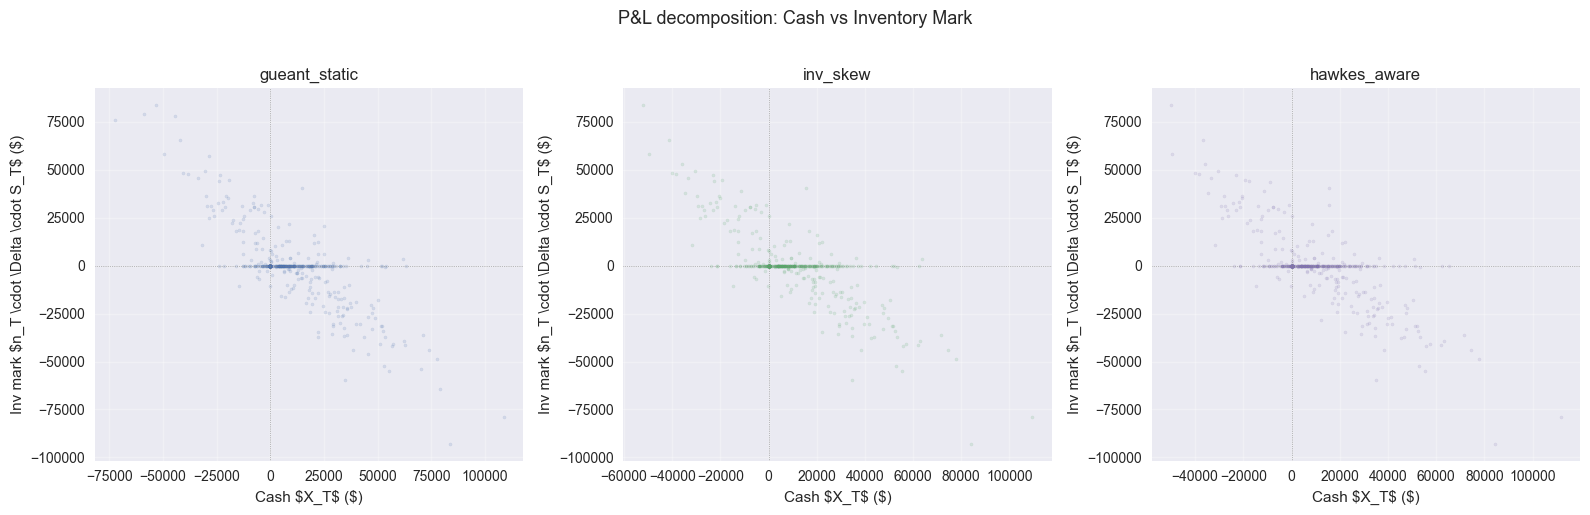

  Policy                 Var(cash)   Var(inv_mark)      Var(P&L)
  ────────────────────────────────────────────────────────────
  gueant_static           4.25e+08        3.39e+08      1.62e+08
  inv_skew                3.74e+08        2.74e+08      1.54e+08
  hawkes_aware            3.73e+08        2.79e+08      1.60e+08


In [14]:

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, color) in zip(axes, [("gueant_static", "C0"), ("inv_skew", "C1"), ("hawkes_aware", "C3")]):
    res = results[name]
    cash_T = res["cash"][:, -1]
    inv_mark = res["inventory"][:, -1].astype(float) * IG["Delta"] * res["price"][:, -1]
    ax.scatter(cash_T, inv_mark, alpha=0.15, s=5, color=color)
    ax.set_xlabel("Cash $X_T$ ($)")
    ax.set_ylabel("Inv mark $n_T \cdot \Delta \cdot S_T$ ($)")
    ax.set_title(name)
    ax.axhline(0, color="gray", ls=":", lw=0.5)
    ax.axvline(0, color="gray", ls=":", lw=0.5)
    ax.grid(alpha=0.3)

fig.suptitle("P&L decomposition: Cash vs Inventory Mark", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

# Variance decomposition
print(f"  {'Policy':<18s}  {'Var(cash)':>12s}  {'Var(inv_mark)':>14s}  {'Var(P&L)':>12s}")
print("  " + "─" * 60)
for name in ["gueant_static", "inv_skew", "hawkes_aware"]:
    res = results[name]
    cash_T = res["cash"][:, -1]
    inv_mark = res["inventory"][:, -1].astype(float) * IG["Delta"] * res["price"][:, -1]
    print(f"  {name:<18s}  {np.var(cash_T):>12.2e}  {np.var(inv_mark):>14.2e}  "
          f"{np.var(res['pnl']):>12.2e}")


## A.6 Reproducibility

In [15]:
import sys
print(f"Python:     {sys.version}")
print(f"NumPy:      {np.__version__}")
import scipy; print(f"SciPy:      {scipy.__version__}")
import matplotlib; print(f"Matplotlib: {matplotlib.__version__}")
print(f"\nScenario:    {SCENARIO}")
print(f"N_sim:       {N_SIM}")
print(f"N_t:         {N_T}")
print(f"T:           {T} s")
print(f"GAMMA:       {GAMMA}")
print(f"Seed:        {SEED}")
print(f"Intensity:   {intensity_model['kind']}")
print(f"Hawkes beta: {hawkes_cfg['beta']}")
print(f"Hawkes j_self:  {hawkes_cfg['jump_self']}")
print(f"Hawkes j_cross: {hawkes_cfg['jump_cross']}")
print(f"Hawkes y_0:     {hawkes_cfg['init_excitation']}")


Python:     3.12.4 (v3.12.4:8e8a4baf65, Jun  6 2024, 17:33:18) [Clang 13.0.0 (clang-1300.0.29.30)]
NumPy:      1.26.4
SciPy:      1.11.4
Matplotlib: 3.7.5

Scenario:    baseline
N_sim:       500
N_t:         600
T:           7200.0 s
GAMMA:       6e-05
Seed:        77
Intensity:   exponential
Hawkes beta: 4.0
Hawkes j_self:  0.0005
Hawkes j_cross: 0.0002
Hawkes y_0:     0.00015
